In [1]:
!pip install pandas numpy matplotlib seaborn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

print('✅ Libraries ready!')

✅ Libraries ready!


In [2]:
import os

# Create output folders in Colab's local session
os.makedirs('/content/outputs/graphs', exist_ok=True)

print('✅ Output folders created!')

✅ Output folders created!


In [3]:
from google.colab import drive
drive.mount('/content/drive')

# ✏️ Update this path to where you saved the CSV in your Drive
EPICLIM_PATH = '/content/drive/MyDrive/DiseaseSpread/dataset/raw_data/epiclim_data.csv'

df = pd.read_csv(EPICLIM_PATH)
print(f'✅ EpiClim loaded!')
print(f'Shape       : {df.shape}')
print(f'Columns     : {df.columns.tolist()}')

Mounted at /content/drive
✅ EpiClim loaded!
Shape       : (8985, 15)
Columns     : ['Unnamed: 0', 'week_of_outbreak', 'state_ut', 'district', 'Disease', 'Cases', 'Deaths', 'day', 'mon', 'year', 'Latitude', 'Longitude', 'preci', 'LAI', 'Temp']


In [4]:
df.head(10)

,Unnamed: 0,week_of_outbreak,state_ut,district,Disease,Cases,Deaths,day,mon,year,Latitude,Longitude,preci,LAI,Temp
0,0,1st week,Meghalaya,East Jaintia Hills,Acute Diarrhoeal Disease,160,NaN,2,1,2022,25.251576,92.484050,0.020354,34.5,291.533333
1,1,2nd week,Maharashtra,Gadchiroli,Malaria,7,2.0,10,1,2022,19.759070,80.162281,0.007479,9.0,299.970000
2,2,3rd week,Tamil Nadu,Pudukottai,Acute Diarrhoeal Disease,8,NaN,18,1,2022,10.382651,78.819126,0.107413,12.0,300.766667
3,3,3rd week,Gujarat,Patan,Acute Diarrhoeal Disease,7,NaN,11,1,2022,23.774057,71.683735,0.065094,9.0,299.080000
4,4,3rd week,Kerala,Ernakulam,Acute Diarrhoeal Disease,14,NaN,24,12,2021,9.984080,76.274146,0.041256,33.0,303.028000
5,5,3rd week,Tamil Nadu,Pudukottai,Acute Diarrhoeal Disease,8,NaN,18,1,2022,10.382651,78.819126,0.107413,12.0,300.766667
6,6,5th week,Uttar Pradesh,Fatehpur,Acute Encephalitis Syndrome,1,NaN,24,1,2022,25.843539,80.918004,0.099030,NaN,290.180000
7,7,6th week,Maharashtra,Gadchiroli,Malaria,1,1.0,9,2,2022,19.759070,80.162281,0.000084,NaN,300.063333
8,8,6th week,Odisha,Koraput,Acute Diarrhoeal Disease,15,NaN,11,2,2022,18.723202,82.608118,0.000491,12.0,300.556667
9,9,7th week,Gujarat,Ahmedabad,Acute Diarrhoeal Disease,67,NaN,17,2,2022,23.021624,72.579707,0.000073,NaN,302.553333


In [5]:
print('=== Data Types ===')
print(df.dtypes)
print(f'\n=== Missing Values ===')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else '✅ No missing values!')

=== Data Types ===
Unnamed: 0            int64
week_of_outbreak     object
state_ut             object
district             object
Disease              object
Cases                object
Deaths              float64
day                   int64
mon                   int64
year                  int64
Latitude            float64
Longitude           float64
preci               float64
LAI                 float64
Temp                float64
dtype: object

=== Missing Values ===
Deaths    6431
preci      136
LAI       2195
Temp       938
dtype: int64


In [6]:
print('=== Statistical Summary ===')
df[['Cases','Deaths','Temp','preci','LAI']].describe().round(3)

=== Statistical Summary ===


,Deaths,Temp,preci,LAI
count,2554.000,8047.000,8849.000,6790.000
mean,1.585,304.520,0.462,10.907
std,5.389,6.980,0.629,7.920
min,0.000,259.680,0.000,0.000
25%,0.000,300.602,0.024,5.000
50%,1.000,303.445,0.225,9.000
75%,1.000,308.590,0.673,14.000
max,147.000,327.728,5.680,62.000


In [7]:
# Fix: convert Cases and Deaths to numeric first
df['Cases']  = pd.to_numeric(df['Cases'],  errors='coerce')
df['Deaths'] = pd.to_numeric(df['Deaths'], errors='coerce')

print(f'Unique States/UTs : {df["state_ut"].nunique()}')
print(f'Unique Districts  : {df["district"].nunique()}')
print(f'Year Range        : {df["year"].min()} — {df["year"].max()}')
print(f'Total Cases       : {df["Cases"].sum():,.0f}')
print(f'Total Deaths      : {df["Deaths"].sum():,.0f}')

print('\n=== Disease Breakdown ===')
print(df['Disease'].value_counts())

Unique States/UTs : 36
Unique Districts  : 791
Year Range        : 2009 — 2022
Total Cases       : 796,427
Total Deaths      : 4,047

=== Disease Breakdown ===
Disease
Acute Diarrhoeal Disease            5126
Dengue                              1619
Chikungunya                          731
Cholera                              666
Malaria                              544
Acute Encephalitis Syndrome          111
Acute Gastroenteritis                100
Dengue And Chikungunya                53
Suspected Dengue                      14
Dengue And Malaria                     3
Suspected Chikungunya                  3
Dengue/Chikungunya                     3
Dengue Fever                           2
Suspected Cholera                      2
pyrexia of unknown origin              1
Malaria (PV)                           1
Dengue Chikungunya                     1
Diarrhea                               1
Gastroenteritis                        1
Suspected Dengue And Chikungunya       1
Chikungunya/

In [8]:
df = pd.read_csv('/content/drive/MyDrive/DiseaseSpread/dataset/raw_data/epiclim_data.csv')

# ← Add these two lines immediately after loading
df['Cases']  = pd.to_numeric(df['Cases'],  errors='coerce')
df['Deaths'] = pd.to_numeric(df['Deaths'], errors='coerce')

print(f'✅ Loaded! Shape: {df.shape}')

✅ Loaded! Shape: (8985, 15)


In [9]:
print('=== Temp is in Kelvin — Preview of Conversion ===')
print(f'Raw Temp range  : {df["Temp"].min():.2f}K  to  {df["Temp"].max():.2f}K')
print(f'In Celsius      : {df["Temp"].min()-273.15:.2f}°C  to  {df["Temp"].max()-273.15:.2f}°C')
print(f'\nPrecipitation range: {df["preci"].min():.4f}  to  {df["preci"].max():.4f} mm')

=== Temp is in Kelvin — Preview of Conversion ===
Raw Temp range  : 259.68K  to  327.73K
In Celsius      : -13.47°C  to  54.58°C

Precipitation range: 0.0000  to  5.6800 mm


In [10]:
df_tn = df[df['state_ut'].str.contains('Tamil', case=False, na=False)]
print(f'Tamil Nadu records : {len(df_tn)}')
print(f'Unique Districts   : {df_tn["district"].nunique()}')
print(f'Diseases present   : {df_tn["Disease"].unique()}')
df_tn.head(8)

Tamil Nadu records : 735
Unique Districts   : 65
Diseases present   : ['Acute Diarrhoeal Disease' 'Dengue' 'pyrexia of unknown origin' 'Cholera'
 'Chikungunya' 'Dengue And Chikungunya' 'Malaria' 'Dengue/Chikungunya']


,Unnamed: 0,week_of_outbreak,state_ut,district,Disease,Cases,Deaths,day,mon,year,Latitude,Longitude,preci,LAI,Temp
2,2,3rd week,Tamil Nadu,Pudukottai,Acute Diarrhoeal Disease,8.0,NaN,18,1,2022,10.382651,78.819126,0.107413,12.0,300.766667
5,5,3rd week,Tamil Nadu,Pudukottai,Acute Diarrhoeal Disease,8.0,NaN,18,1,2022,10.382651,78.819126,0.107413,12.0,300.766667
26,26,10th week,Tamil Nadu,Ariyalur,Dengue,6.0,NaN,5,2,2022,11.076036,79.117455,0.012509,10.0,303.384000
27,27,10th week,Tamil Nadu,Ariyalur,pyrexia of unknown origin,15.0,NaN,31,1,2022,11.076036,79.117455,0.083090,10.0,300.355000
28,28,10th week,Tamil Nadu,Virudhunagar,Dengue,17.0,NaN,16,2,2022,9.520894,77.878456,0.307975,7.0,306.000000
38,38,12th week,Tamil Nadu,Ariyalur,Acute Diarrhoeal Disease,14.0,NaN,24,3,2022,11.076036,79.117455,0.003166,8.0,308.436000
48,48,13th week,Tamil Nadu,Pudukkottai,Dengue,15.0,NaN,30,3,2022,10.500000,78.833333,0.067214,NaN,306.370000
54,54,15th week,Tamil Nadu,Kallakurichi,Acute Diarrhoeal Disease,14.0,NaN,17,4,2022,11.740626,78.963713,0.351280,10.0,312.570000


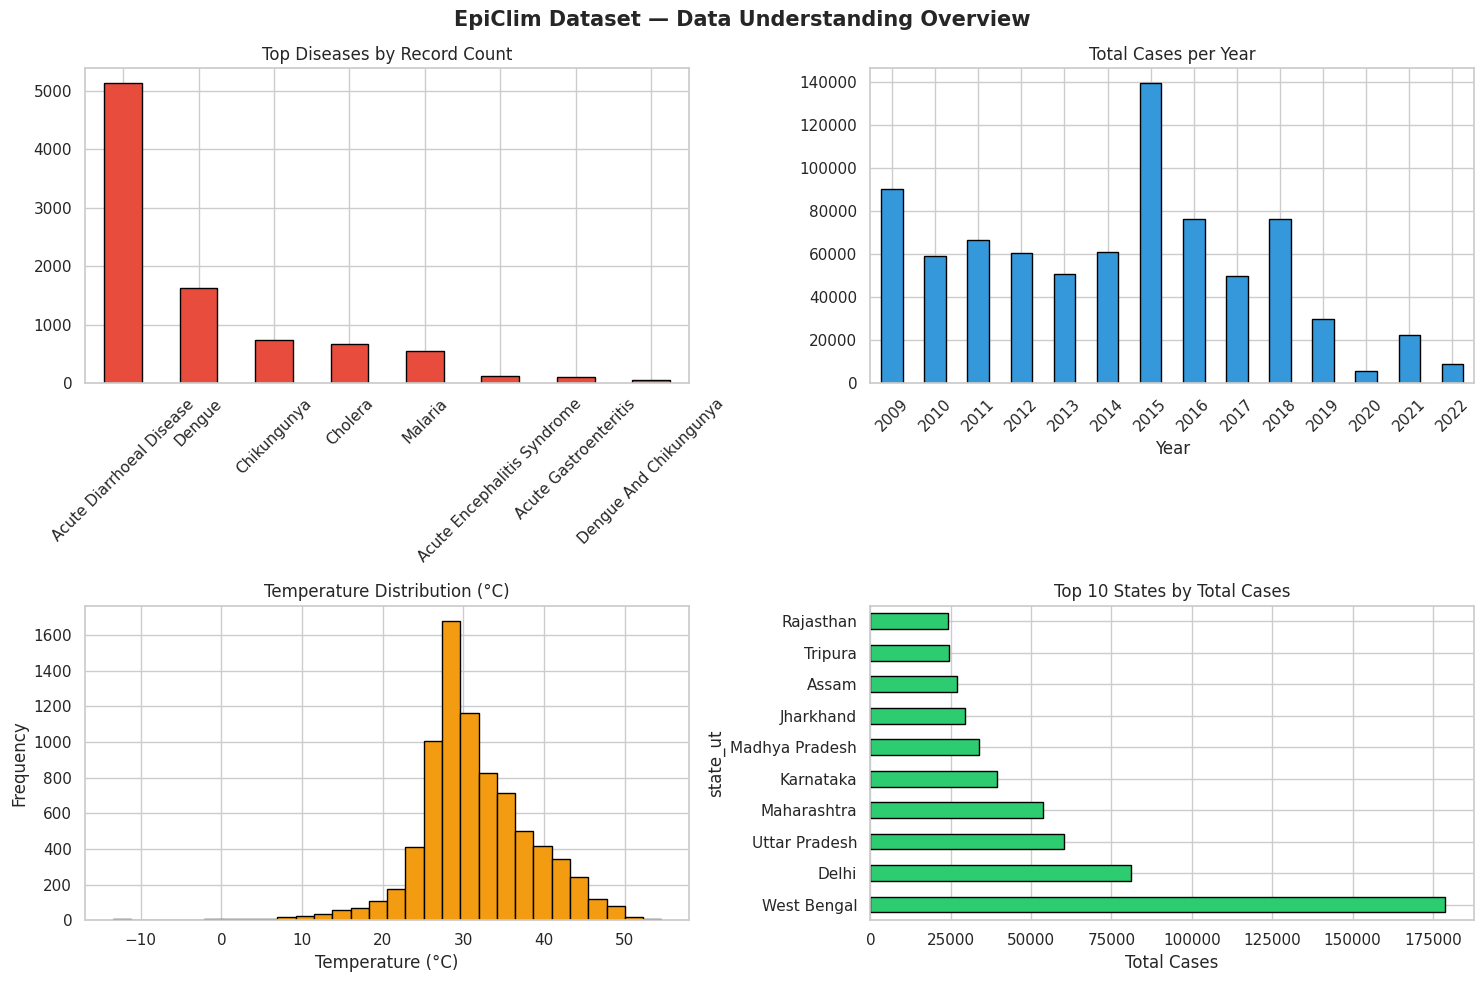

✅ Chart saved → outputs/graphs/data_overview.png


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('EpiClim Dataset — Data Understanding Overview', fontsize=15, fontweight='bold')

# 1. Disease distribution
df['Disease'].value_counts().head(8).plot(
    kind='bar', ax=axes[0,0], color='#e74c3c', edgecolor='black')
axes[0,0].set_title('Top Diseases by Record Count')
axes[0,0].set_xlabel('')
axes[0,0].tick_params(axis='x', rotation=45)

# 2. Cases per year
df.groupby('year')['Cases'].sum().plot(
    kind='bar', ax=axes[0,1], color='#3498db', edgecolor='black')
axes[0,1].set_title('Total Cases per Year')
axes[0,1].set_xlabel('Year')
axes[0,1].tick_params(axis='x', rotation=45)

# 3. Temperature histogram (Kelvin → Celsius)
axes[1,0].hist(df['Temp'] - 273.15, bins=30, color='#f39c12', edgecolor='black')
axes[1,0].set_title('Temperature Distribution (°C)')
axes[1,0].set_xlabel('Temperature (°C)')
axes[1,0].set_ylabel('Frequency')

# 4. Top 10 states by cases
df.groupby('state_ut')['Cases'].sum().sort_values(ascending=False).head(10).plot(
    kind='barh', ax=axes[1,1], color='#2ecc71', edgecolor='black')
axes[1,1].set_title('Top 10 States by Total Cases')
axes[1,1].set_xlabel('Total Cases')

plt.tight_layout()
plt.savefig('/content/outputs/graphs/data_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart saved → outputs/graphs/data_overview.png')

In [12]:
total_records = df.shape[0]
min_year = df['year'].min()
max_year = df['year'].max()
states_covered = df['state_ut'].nunique()
diseases_covered = df['Disease'].unique().tolist()
missing_values = df.isnull().sum()
missing_values_str = '\n'.join([f'{col}: {count}' for col, count in missing_values.items() if count > 0])

print(f"Total Records: {total_records}")
print(f"Year Range: {min_year} – {max_year}")
print(f"States Covered: {states_covered}")
print(f"Diseases Covered: {', '.join(diseases_covered)}")
print(f"Missing Values:\n{missing_values_str}")

Total Records: 8985
Year Range: 2009 – 2022
States Covered: 36
Diseases Covered: Acute Diarrhoeal Disease, Malaria, Acute Encephalitis Syndrome, Acute Gastroenteritis, Dengue, pyrexia of unknown origin, Chikungunya, Cholera, Malaria (PV), Dengue Fever, Suspected Dengue, Dengue Chikungunya, Dengue And Chikungunya, Suspected Cholera, Diarrhea, Suspected Chikungunya, Suspected Dengue And Chikungunya, Gastroenteritis, Dengue And Malaria, Dengue/Chikungunya, Chikungunya/Dengue, Chikungunya/ Dengue
Missing Values:
Cases: 1
Deaths: 6431
preci: 136
LAI: 2195
Temp: 938
